Integrantes:
- Cristóbal Salvo
- Fernando Núñez
- Fabian Mejías
- Cristóbal Valenzuela

Asignatura: Ciencia de Datos (NRC: 7931)

In [7]:
############################################
### NO ES NECESARIO EJECUTAR ESTE CODIGO ###
############################################

# Instalación de Apache Spark en Google Colab
#!apt-get install openjdk-8-jdk-headless -qq > /dev/null
#!wget -q https://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz
#!tar xf spark-3.5.0-bin-hadoop3.tgz
#!pip install -q findspark
#!pip install seaborn

#import os
# Configuramos las variables de entorno
#os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
#os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"

#import findspark
#findspark.init() 

In [8]:
import os
import sys
from pyspark.sql import SparkSession

# Configuración para evitar conflictos de versiones de Python (Aplica para local, Colab lo ignora o asimila)
os.environ['PYSPARK_PYTHON'] = sys.executable
os.environ['PYSPARK_DRIVER_PYTHON'] = sys.executable

# 1. Intentar detener cualquier sesión previa que haya quedado colgada en este kernel
try:
    SparkSession.builder.getOrCreate().stop()
except:
    pass

# 2. Crear sesión de Spark unificada (Compatible Local y Colab)
spark = SparkSession.builder \
    .appName("AnalisisMortalidad_Egresos2024") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "10") \
    .config("spark.driver.maxResultSize", "2g") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "2g") \
    .getOrCreate()

print("✅ Sesión de Spark iniciada correctamente.")

✅ Sesión de Spark iniciada correctamente.


In [9]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("AnalisisEgresos2024") \
    .getOrCreate()

# TIENEN QUE PEGAR EL ARCHIVO EGRESOS_2024.csv EN EL LOCAL DEL COLAB
df = spark.read.csv(
    './data/EGRESOS_2024.csv',
    header=True,
    inferSchema=True,
    sep=';'
)

df.show(5)

26/04/29 01:07:11 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


+---------------------------------+----+------------+-----------------+-----------------+-----------------------+-----------------+-----------------------+---------+---------------+----------+-----+-----+-----------+----------------+
|PERTENENCIA_ESTABLECIMIENTO_SALUD|SEXO|  GRUPO_EDAD|GLOSA_PAIS_ORIGEN|COMUNA_RESIDENCIA|GLOSA_COMUNA_RESIDENCIA|REGION_RESIDENCIA|GLOSA_REGION_RESIDENCIA|PREVISION|GLOSA_PREVISION|ANO_EGRESO|DIAG1|DIAG2|DIAS_ESTADA|CONDICION_EGRESO|
+---------------------------------+----+------------+-----------------+-----------------+-----------------------+-----------------+-----------------------+---------+---------------+----------+-----+-----+-----------+----------------+
|             Pertenecientes al...|   2|20 A 24 A�OS|        Argentina|            01101|                Iquique|               01|            De Tarapac�|        1|         FONASA|      2024| N908| NULL|          2|               1|
|             Pertenecientes al...|   2|25 A 29 A�OS|        Arg

In [10]:
#########################
### Analisis de datos ###
#########################

In [11]:
# Ver la estructura del dataset y los tipos de datos inferidos
df.printSchema()

root
 |-- PERTENENCIA_ESTABLECIMIENTO_SALUD: string (nullable = true)
 |-- SEXO: string (nullable = true)
 |-- GRUPO_EDAD: string (nullable = true)
 |-- GLOSA_PAIS_ORIGEN: string (nullable = true)
 |-- COMUNA_RESIDENCIA: string (nullable = true)
 |-- GLOSA_COMUNA_RESIDENCIA: string (nullable = true)
 |-- REGION_RESIDENCIA: string (nullable = true)
 |-- GLOSA_REGION_RESIDENCIA: string (nullable = true)
 |-- PREVISION: string (nullable = true)
 |-- GLOSA_PREVISION: string (nullable = true)
 |-- ANO_EGRESO: integer (nullable = true)
 |-- DIAG1: string (nullable = true)
 |-- DIAG2: string (nullable = true)
 |-- DIAS_ESTADA: integer (nullable = true)
 |-- CONDICION_EGRESO: integer (nullable = true)



-------------

In [12]:
# Ver la distribución, cuartiles y posibles valores atípicos
df.select("DIAS_ESTADA").summary("count", "mean", "stddev", "min", "25%", "50%", "75%", "max").show()

+-------+-----------------+
|summary|      DIAS_ESTADA|
+-------+-----------------+
|  count|          1667349|
|   mean| 6.09228781736757|
| stddev|40.36283456240756|
|    min|                1|
|    25%|                1|
|    50%|                2|
|    75%|                6|
|    max|            17858|
+-------+-----------------+



In [13]:
# Revisar valores únicos en SEXO (¿hay algo más aparte de 1 y 2?)
df.groupBy("SEXO").count().orderBy("count").show()

# Revisar los grupos de edad (para ver si hay formatos inconsistentes)
df.groupBy("GRUPO_EDAD").count().orderBy("GRUPO_EDAD").show(30, truncate=False)

# Revisar Previsión
df.groupBy("GLOSA_PREVISION").count().orderBy("count").show(truncate=False)

+----+------+
|SEXO| count|
+----+------+
|   *| 28382|
|   1|704881|
|   2|934086|
+----+------+

+------------------------+------+
|GRUPO_EDAD              |count |
+------------------------+------+
|1 A 4 A�OS              |53829 |
|10 A 14 A�OS            |46948 |
|15 A 19 A�OS            |54348 |
|2 MESES A MENOS DE 1 A�O|18914 |
|20 A 24 A�OS            |80340 |
|25 A 29 A�OS            |110946|
|28 DIAS A 2 MES         |3984  |
|30 A 34 A�OS            |137464|
|35 A 39 A�OS            |125138|
|40 A 44 A�OS            |99615 |
|45 A 49 A�OS            |87462 |
|5 A 9 A�OS              |52588 |
|50 A 54 A�OS            |91040 |
|55 A 59 A�OS            |102125|
|60 A 64 A�OS            |115953|
|65 A 69 A�OS            |116720|
|7 A 27 DIAS             |5281  |
|70 A 74 A�OS            |104227|
|75 A 79 A�OS            |92283 |
|80 A 84 A�OS            |69633 |
|85 A MAS                |71185 |
|menor a 7 d�as          |27326 |
+------------------------+------+

+---------------

In [14]:
##############################
### Procesamiento de datos ###
##############################

In [15]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, MinMaxScaler
from pyspark.ml import Pipeline
from pyspark.sql.functions import col, when, substring

# 1. LIMPIEZA Y FILTRO INICIAL
df_clean = df.filter(
    (col("SEXO") != "*") &
    (col("GLOSA_PREVISION") != "*") &
    col("CONDICION_EGRESO").isNotNull()
).filter(
    ~((col("SEXO") == "1") & (col("DIAG1").startswith("O")))
)

# 2. INGENIERÍA DE CARACTERÍSTICAS
df_ml = df_clean.withColumn(
    "PREVISION_GRUPAL",
    when(col("GLOSA_PREVISION").isin("FONASA", "ISAPRE"), col("GLOSA_PREVISION"))
    .otherwise("OTRAS_O_FF.AA")
).withColumn(
    "EDAD_SIMPLIFICADA",
    when(col("GRUPO_EDAD").rlike("MES|DIA|menor|1 A 4|5 A 9|10 A 14"), "PEDIATRICO")
    .when(col("GRUPO_EDAD").rlike("15 A 19|20 A 24|25 A 29"), "JOVEN")
    .when(col("GRUPO_EDAD").rlike("30 A 34|35 A 39|40 A 44|45 A 49|50 A 54|55 A 59"), "ADULTO")
    .otherwise("ADULTO_MAYOR")
).withColumn(
    "DIAG1_GRUPO", substring(col("DIAG1"), 1, 1)
).withColumn(
    "TIENE_DIAG2",
    when(col("DIAG2").isNull() | (col("DIAG2") == "") | (col("DIAG2") == "SIN_DIAG2"), "NO")
    .otherwise("SI")
).withColumn(
    "DIAS_ESTADA_NUM", col("DIAS_ESTADA").cast("double")
).withColumn(
    "label", when(col("CONDICION_EGRESO") == 2, 1.0).otherwise(0.0) 
)

# --- BLOQUE DE BALANCEO DE CLASES (UNDERSAMPLING) ---
# Esto evita que el modelo prediga siempre "VIVO"
df_vivos = df_ml.filter(col("label") == 0.0)
df_fallecidos = df_ml.filter(col("label") == 1.0)

ratio = df_fallecidos.count() / df_vivos.count()
df_vivos_sub = df_vivos.sample(withReplacement=False, fraction=ratio, seed=256)

# Unimos para tener un dataset 50/50
df_balanced = df_vivos_sub.unionByName(df_fallecidos)
# ----------------------------------------------------

# 3. DEFINICIÓN DE VARIABLES PARA EL MODELO
CAT_COLS = [
    "SEXO", "EDAD_SIMPLIFICADA", "PREVISION_GRUPAL", 
    "DIAG1_GRUPO", "TIENE_DIAG2", "PERTENENCIA_ESTABLECIMIENTO_SALUD",
    "GLOSA_PAIS_ORIGEN"
]
NUM_COLS = ["DIAS_ESTADA_NUM"] 

# Ahora usamos df_balanced en lugar de df_ml
df_prepared_input = df_balanced.select(CAT_COLS + NUM_COLS + ["label"]).dropna()

# 4. CONSTRUCCIÓN DEL PIPELINE
indexers = [StringIndexer(inputCol=c, outputCol=c+"_idx", handleInvalid="keep") for c in CAT_COLS]
encoders = [OneHotEncoder(inputCol=c+"_idx", outputCol=c+"_ohe") for c in CAT_COLS]

num_assembler = VectorAssembler(inputCols=NUM_COLS, outputCol="num_features_raw")
scaler = MinMaxScaler(inputCol="num_features_raw", outputCol="scaled_num_features")

assembler_inputs = [c+"_ohe" for c in CAT_COLS] + ["scaled_num_features"]
final_assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="features")

# Pipeline completo
pipeline = Pipeline(stages=indexers + encoders + [num_assembler, scaler, final_assembler])
pipeline_model = pipeline.fit(df_prepared_input)
df_final = pipeline_model.transform(df_prepared_input)

# División de datos (80% Entrenamiento, 20% Prueba)
train_data, test_data = df_final.randomSplit([0.8, 0.2], seed=256)
train_data.cache()

26/04/29 01:07:36 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


DataFrame[SEXO: string, EDAD_SIMPLIFICADA: string, PREVISION_GRUPAL: string, DIAG1_GRUPO: string, TIENE_DIAG2: string, PERTENENCIA_ESTABLECIMIENTO_SALUD: string, GLOSA_PAIS_ORIGEN: string, DIAS_ESTADA_NUM: double, label: double, SEXO_idx: double, EDAD_SIMPLIFICADA_idx: double, PREVISION_GRUPAL_idx: double, DIAG1_GRUPO_idx: double, TIENE_DIAG2_idx: double, PERTENENCIA_ESTABLECIMIENTO_SALUD_idx: double, GLOSA_PAIS_ORIGEN_idx: double, SEXO_ohe: vector, EDAD_SIMPLIFICADA_ohe: vector, PREVISION_GRUPAL_ohe: vector, DIAG1_GRUPO_ohe: vector, TIENE_DIAG2_ohe: vector, PERTENENCIA_ESTABLECIMIENTO_SALUD_ohe: vector, GLOSA_PAIS_ORIGEN_ohe: vector, num_features_raw: vector, scaled_num_features: vector, features: vector]

In [16]:
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

# Evaluador principal para Clasificación Binaria (Área bajo la curva ROC)
evaluator_roc = BinaryClassificationEvaluator(metricName="areaUnderROC")

# ---------------------------------------------------------
# ENFOQUE A: Regresión Logística con Regularización (Elastic Net)
# ---------------------------------------------------------
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=20)

# Grilla de hiperparámetros: 
# elasticNetParam: 0.0 (Ridge/L2), 1.0 (Lasso/L1), 0.5 (Combinado)
paramGrid_lr = ParamGridBuilder() \
    .addGrid(lr.regParam, [0.01, 0.1]) \
    .addGrid(lr.elasticNetParam, [0.0, 0.5, 1.0]) \
    .build()

cv_lr = CrossValidator(estimator=lr,
                       estimatorParamMaps=paramGrid_lr,
                       evaluator=evaluator_roc,
                       numFolds=3,
                       seed=256)

print("Entrenando Regresión Logística (CrossValidation)...")
cvModel_lr = cv_lr.fit(train_data)
pred_lr = cvModel_lr.transform(test_data)
auc_lr = evaluator_roc.evaluate(pred_lr)

# ---------------------------------------------------------
# ENFOQUE B: Random Forest Classifier
# ---------------------------------------------------------
rf = RandomForestClassifier(featuresCol="features", labelCol="label", seed=256)

paramGrid_rf = ParamGridBuilder() \
    .addGrid(rf.maxDepth, [5, 10]) \
    .addGrid(rf.numTrees, [20, 50]) \
    .build()

cv_rf = CrossValidator(estimator=rf,
                       estimatorParamMaps=paramGrid_rf,
                       evaluator=evaluator_roc,
                       numFolds=3,
                       seed=256)

print("Entrenando Random Forest (CrossValidation)...")
cvModel_rf = cv_rf.fit(train_data)

# AQUÍ ESTÁ EL TRUCO: Forzamos a Spark a guardar el resultado para no recalcular
pred_rf = cvModel_rf.transform(test_data)
pred_rf.cache() 

auc_rf = evaluator_roc.evaluate(pred_rf)

Entrenando Regresión Logística (CrossValidation)...


Entrenando Random Forest (CrossValidation)...


26/04/29 01:09:03 WARN DAGScheduler: Broadcasting large task binary with size 1073.6 KiB
26/04/29 01:09:06 WARN DAGScheduler: Broadcasting large task binary with size 1029.2 KiB
26/04/29 01:09:06 WARN DAGScheduler: Broadcasting large task binary with size 1344.8 KiB
26/04/29 01:09:07 WARN DAGScheduler: Broadcasting large task binary with size 1714.6 KiB
26/04/29 01:09:08 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/04/29 01:09:09 WARN DAGScheduler: Broadcasting large task binary with size 1262.5 KiB
26/04/29 01:09:16 WARN DAGScheduler: Broadcasting large task binary with size 1076.1 KiB
26/04/29 01:09:19 WARN DAGScheduler: Broadcasting large task binary with size 1025.9 KiB
26/04/29 01:09:19 WARN DAGScheduler: Broadcasting large task binary with size 1355.9 KiB
26/04/29 01:09:20 WARN DAGScheduler: Broadcasting large task binary with size 1732.3 KiB
26/04/29 01:09:21 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/04/29 01:09:22 WARN DAGS

In [17]:
############################
### Evaluacion de modelo ###
############################

In [18]:
# ---------------------------------------------------------
# RESULTADOS FINALES
# ---------------------------------------------------------
print("\n--- COMPARACIÓN DE MODELOS (MORTALIDAD) ---")
print(f"AUC-ROC Regresión Logística: {auc_lr:.4f}")
print(f"AUC-ROC Random Forest:       {auc_rf:.4f}")

# Obtener el mejor hiperparámetro del modelo LR (para ver si eligió L1 o L2)
best_lr = cvModel_lr.bestModel
print(f"\nMejor parámetro de Regularización LR (ElasticNet): {best_lr._java_obj.getElasticNetParam()}")


--- COMPARACIÓN DE MODELOS (MORTALIDAD) ---
AUC-ROC Regresión Logística: 0.8636
AUC-ROC Random Forest:       0.8709

Mejor parámetro de Regularización LR (ElasticNet): 0.0


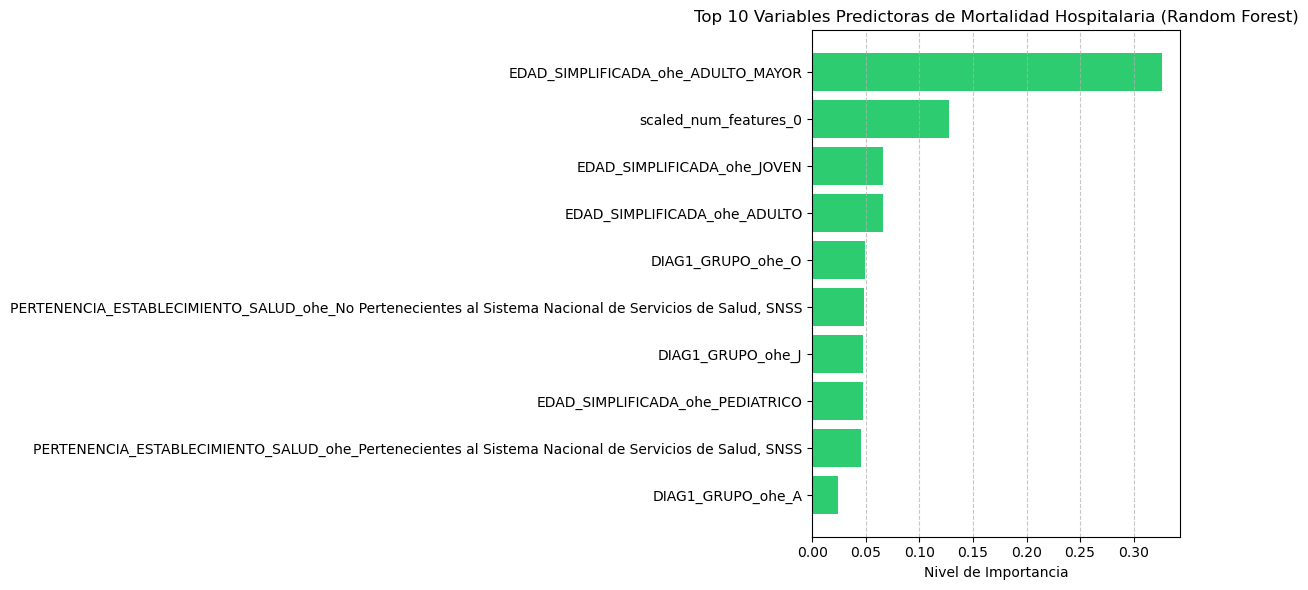

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Extraer el mejor modelo de Random Forest validado
best_rf = cvModel_rf.bestModel

# 2. Extraer los pesos de importancia de la matriz matemática
importances = best_rf.featureImportances

# 3. Leer los metadatos de Spark para recuperar los nombres reales de las columnas
attrs = df_final.schema["features"].metadata["ml_attr"]["attrs"]
feature_names = []
for attr_type in ["numeric", "binary", "nominal"]:
    if attr_type in attrs:
        feature_names.extend([
            (attr["idx"], attr["name"]) for attr in attrs[attr_type]
        ])
        
# Ordenar para que coincidan con el vector
feature_names.sort(key=lambda x: x[0])
names = [x[1] for x in feature_names]

# 4. Crear un DataFrame de Pandas con el Top 10 y graficar
df_importances = pd.DataFrame({
    "Característica": names,
    "Importancia": importances.toArray()
}).sort_values(by="Importancia", ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(df_importances["Característica"][::-1], df_importances["Importancia"][::-1], color='#2ecc71')
plt.xlabel("Nivel de Importancia")
plt.title("Top 10 Variables Predictoras de Mortalidad Hospitalaria (Random Forest)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

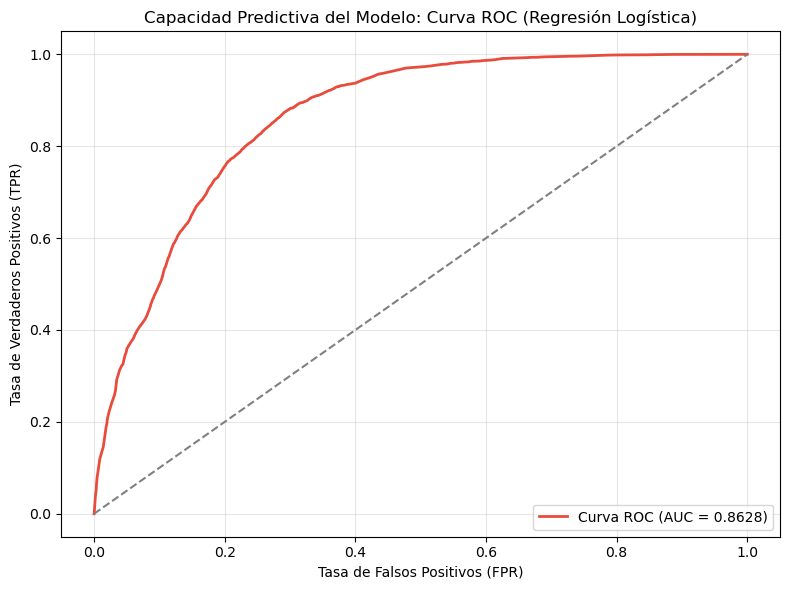

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extraer los datos de la curva ROC del resumen de entrenamiento del mejor modelo LR
# Nota: summary solo está disponible en el modelo de regresión logística base
lr_summary = cvModel_lr.bestModel.summary
roc = lr_summary.roc.toPandas()

plt.figure(figsize=(8, 6))
plt.plot(roc['FPR'], roc['TPR'], color='#e74c3c', linewidth=2, label=f'Curva ROC (AUC = {lr_summary.areaUnderROC:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--') # Línea base aleatoria
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Capacidad Predictiva del Modelo: Curva ROC (Regresión Logística)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
import pandas as pd
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# 1. Agrupar y contar usando Spark 
cm_spark = pred_rf.groupBy("label", "prediction").count().toPandas()

# 2. Formatear la matriz en Pandas para evitar los bugs visuales de Java
df_confusion = pd.DataFrame(0, index=[0.0, 1.0], columns=[0.0, 1.0]) 

# Llenamos la matriz con los conteos reales
for _, row in cm_spark.iterrows():
    df_confusion.at[row['label'], row['prediction']] = row['count']

# Renombramos para que sea fácil de leer en tu presentación
df_confusion.index = ['Real: VIVO (0.0)', 'Real: FALLECIDO (1.0)']
df_confusion.columns = ['Pred: VIVO', 'Pred: FALLECIDO']

print("--- MATRIZ DE CONFUSIÓN ---")
print(df_confusion)
print("\n")

# 3. Configurar los evaluadores para la clase positiva (1.0 = Fallecidos)
eval_precision = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="precisionByLabel", metricLabel=1.0)

eval_recall = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="recallByLabel", metricLabel=1.0)

eval_f1 = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction", metricName="fMeasureByLabel", metricLabel=1.0)

# 4. Calcular e imprimir las métricas
precision = eval_precision.evaluate(pred_rf)
recall = eval_recall.evaluate(pred_rf)
f1 = eval_f1.evaluate(pred_rf)

print("--- MÉTRICAS DETALLADAS (Clase: Fallecidos) ---")
print(f"Precisión:           {precision:.4f}")
print(f"Sensibilidad/Recall: {recall:.4f}")
print(f"F1-Score:            {f1:.4f}")

26/04/29 01:09:47 WARN DAGScheduler: Broadcasting large task binary with size 1323.2 KiB


--- MATRIZ DE CONFUSIÓN ---
                       Pred: VIVO  Pred: FALLECIDO
Real: VIVO (0.0)             5763             2188
Real: FALLECIDO (1.0)        1030             6879




26/04/29 01:09:47 WARN DAGScheduler: Broadcasting large task binary with size 1317.8 KiB
26/04/29 01:09:47 WARN DAGScheduler: Broadcasting large task binary with size 1317.8 KiB
26/04/29 01:09:48 WARN DAGScheduler: Broadcasting large task binary with size 1317.8 KiB


--- MÉTRICAS DETALLADAS (Clase: Fallecidos) ---
Precisión:           0.7587
Sensibilidad/Recall: 0.8698
F1-Score:            0.8104


26/04/29 01:09:56 WARN DAGScheduler: Broadcasting large task binary with size 1073.6 KiB
26/04/29 01:10:00 WARN DAGScheduler: Broadcasting large task binary with size 1029.2 KiB
26/04/29 01:10:00 WARN DAGScheduler: Broadcasting large task binary with size 1344.8 KiB
26/04/29 01:10:01 WARN DAGScheduler: Broadcasting large task binary with size 1714.6 KiB
26/04/29 01:10:02 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/04/29 01:10:03 WARN DAGScheduler: Broadcasting large task binary with size 1262.5 KiB
26/04/29 01:10:10 WARN DAGScheduler: Broadcasting large task binary with size 1076.1 KiB
26/04/29 01:10:13 WARN DAGScheduler: Broadcasting large task binary with size 1025.9 KiB
26/04/29 01:10:14 WARN DAGScheduler: Broadcasting large task binary with size 1355.9 KiB
26/04/29 01:10:14 WARN DAGScheduler: Broadcasting large task binary with size 1732.3 KiB
26/04/29 01:10:15 WARN DAGScheduler: Broadcasting large task binary with size 2.1 MiB
26/04/29 01:10:16 WARN DAGS

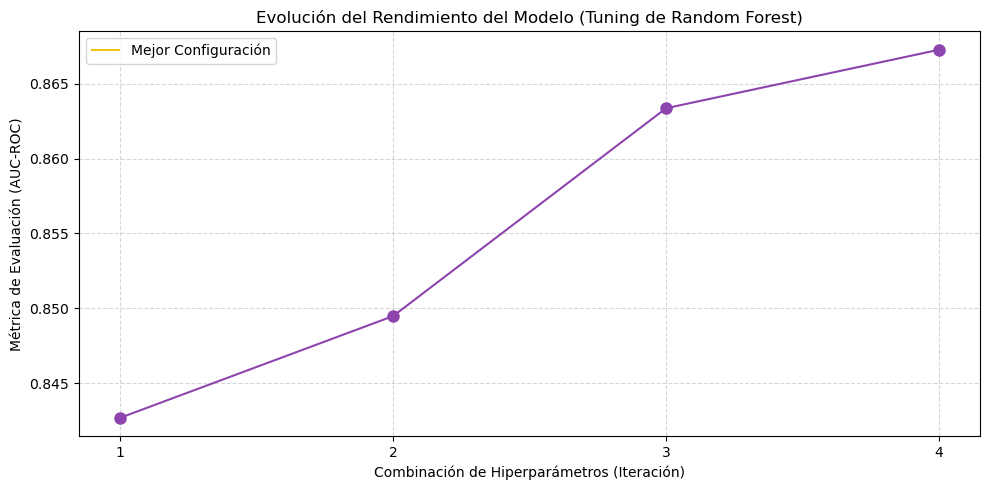

In [22]:
import numpy as np

# 1. Extraer el promedio de la métrica (AUC) para cada combinación que probó el CV
rf_metrics = cv_rf.fit(train_data).avgMetrics 

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(rf_metrics) + 1), rf_metrics, marker='o', linestyle='-', color='#8e44ad', markersize=8)
plt.xlabel('Combinación de Hiperparámetros (Iteración)')
plt.ylabel('Métrica de Evaluación (AUC-ROC)')
plt.title('Evolución del Rendimiento del Modelo (Tuning de Random Forest)')
plt.xticks(range(1, len(rf_metrics) + 1))
plt.grid(True, linestyle='--', alpha=0.5)

# Resaltar el mejor modelo
best_idx = np.argmax(rf_metrics)
plt.plot(best_idx + 1, rf_metrics[best_idx], color='#f1c40f', markersize=15, label='Mejor Configuración')
plt.legend()
plt.tight_layout()
plt.show()